Nonlinear sphere 3D kinematics (strain-displacement relations)
---
Engineering Mechanics Stability

Graduate School Course

Author: Saullo G. P. Castro

Date: 8 July 2025

In [1]:
from sympy import Function, Symbol, sqrt, cos, sin
from sympy import init_printing, simplify, expand

r = Symbol('r', constant=True)
phi = Symbol('phi')
theta = Symbol('theta')
z = Symbol('z')
u = Function('u')(phi,theta,z)
v = Function('v')(phi,theta,z)
w = Function('w')(phi,theta,z)
R = Function('R')(z)

NL = 0 # NOTE set to 1 for full nonlinear relations, 0 for linear relations

# Global coordinates
X1 = R*cos(phi)*cos(theta)
X2 = R*sin(phi)*cos(theta)
X3 = R*sin(theta)

# Local coordinates
x1 = phi
x2 = theta
x3 = z

H1 = sqrt(X1.diff(x1)**2 + X2.diff(x1)**2 + X3.diff(x1)**2)
H2 = sqrt(X1.diff(x2)**2 + X2.diff(x2)**2 + X3.diff(x2)**2)
H3 = sqrt(X1.diff(x3)**2 + X2.diff(x3)**2 + X3.diff(x3)**2)
                
w1 = ((H1*w).diff(x2) - (H2*v).diff(x3))/(2*H2*H3)
w2 = ((H1*u).diff(x3) - (H3*w).diff(x1))/(2*H1*H3)
w3 = ((H2*v).diff(x1) - (H1*u).diff(x2))/(2*H1*H2)

e11 = u.diff(x1)/H1 + v*H1.diff(x2)/(H1*H2) + w*H1.diff(x3)/(H1*H3)
e22 = u*H2.diff(x1)/(H1*H2) + v.diff(x2)/H2 + w*H2.diff(x3)/(H2*H3)
e33 = u*H3.diff(x1)/(H1*H3) + v*H3.diff(x2)/(H2*H3) + w.diff(x3)/H3
e12 = H1*(u/H1).diff(x2)/H2 + H2*(v/H2).diff(x1)/H1
e13 = H1*(u/H1).diff(x3)/H3 + H3*(w/H3).diff(x1)/H1
e23 = H2*(v/H2).diff(x3)/H3 + H3*(w/H3).diff(x2)/H2

ep11 = ((e13/2 - w2)**2 + (e12/2 + w3)**2 + e11**2)/2*NL + e11
ep22 = ((e23/2 + w1)**2 + (e12/2 - w3)**2 + e22**2)/2*NL + e22
ep33 = ((e23/2 - w1)**2 + (e13/2 + w2)**2 + e33**2)/2*NL + e33
ep12 = ((e23/2 + w1)*(e13/2 - w2) + e11*(e12/2 - w3) + e22*(e12/2 + w3))*NL + e12
ep13 = (e33*(e13/2 - w2) + e11*(e13/2 + w2) + (e23/2 - w1)*(e12/2 + w3))*NL + e13
ep23 = (e22*(e23/2 - w1) + e33*(e23/2 + w1) + (e13/2 + w2)*(e12/2 - w3))*NL + e23

epp = ep11
ett = ep22
ezz = ep33
gpt = ep12
gpz = ep13
gtz = ep23


Printing kinematic equations
---
The following order is printed next:

$\varepsilon_{\phi\phi}$
$\varepsilon_{\theta\theta}$
$\varepsilon_{zz}$
$\gamma_{\phi\theta}$
$\gamma_{\phi z}$
$\gamma_{\theta z}$


In [2]:
init_printing()

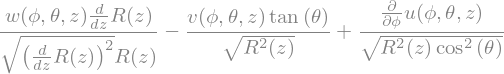

In [3]:
simplify(epp)

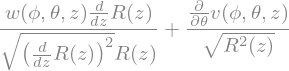

In [4]:
simplify(ett)

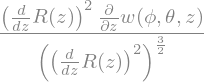

In [5]:
simplify(ezz)

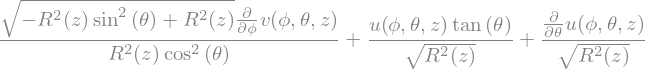

In [6]:
simplify(gpt)

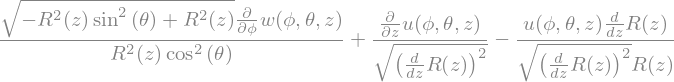

In [7]:
simplify(gpz)

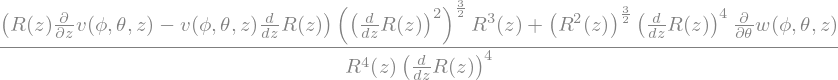

In [8]:
simplify(gtz)